# Version 3.0

## Libraries and imports

In [27]:
# Libraries
import sys
sys.path.append('..')
from feature_selection import data_feature_selection, split_data, split_data_3way, data_feature_selection_3way


import numpy as np
from datetime import datetime
import pandas as pd
import requests
import time
from numpy._core.defchararray import zfill
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import os
import gc
from os import scandir, mkdir
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Conv1D, BatchNormalization, Activation, Add, GlobalAveragePooling1D, GRU
from tensorflow.keras.callbacks import EarlyStopping
import itertools
import tensorflow as tf

#import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Get the dataset
df_ml = pd.read_csv("../../data/processed/DatasetMaster.csv")
df_ml.columns


Index(['time', 'temperature_2m', 'precipitation', 'relative_humidity_2m',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'runoff', 'et0_fao_evapotranspiration',
       'wind_speed_10m', 'wind_gusts_10m', 'alcaldia', 'tema_solicitud',
       'severidad', 'incident', 'mes', 'dia_semana', 'hora_del_dia',
       'es_fin_de_semana', 'precipitation_sum_3h',
       'soil_moisture_0_to_7cm_mean_3h', 'soil_moisture_7_to_28cm_mean_3h',
       'relative_humidity_2m_mean_3h', 'precipitation_sum_6h',
       'soil_moisture_0_to_7cm_mean_6h', 'soil_moisture_7_to_28cm_mean_6h',
       'relative_humidity_2m_mean_6h', 'precipitation_sum_12h',
       'soil_moisture_0_to_7cm_mean_12h', 'soil_moisture_7_to_28cm_mean_12h',
       'relative_humidity_2m_mean_12h', 'precipitation_sum_24h',
       'soil_moisture_0_to_7cm_mean_24h', 'soil_moisture_7_to_28cm_mean_24h',
       'relative_humidity_2m_mean_24h'],
      dtype='object')

In [3]:
# Split data function
X_train, X_test, y_train, y_test = split_data(df_ml)

In [4]:
# Feature selection
X_train, X_test = data_feature_selection(X_train, X_test)

Original Feature Count: 48
Cleaned Feature Count:  37


Use StandardScaler to normalize the values

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Create sequences for temporal models. We use `window_size=24` because the data is hourly.

In [6]:
def create_sequences(X, y, window_size):
    X_seq = []
    y_seq = []

    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y.iloc[i])

    return np.array(X_seq), np.array(y_seq)

In [7]:
window_size = 24
X_train_tcn, y_train_tcn = create_sequences(X_train_scaled, y_train, window_size)
X_test_tcn, y_test_tcn = create_sequences(X_test_scaled, y_test, window_size)

print(X_train_tcn.shape)
print(y_train_tcn.shape)

(854287, 24, 37)
(854287,)


We need to calculate class weights in order to train the model using balanced weights, compensating for the class imbalance between flood and non-flood events.

In [8]:
classes = np.unique(y_train_tcn)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_tcn
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5675247095900713), np.int64(1): np.float64(4.202348392428476)}


## Model creation

In [9]:
# Build TCN residual block
def residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate):

    # Save the original input for the residual connection
    shortcut = x

    # Apply a causal temporal convolution to learn temporal patterns
    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal"
    )(x)

    # Normalize activations to stabilize training
    x = BatchNormalization()(x)

    # Apply non-linearity to learn complex relationships
    x = Activation("relu")(x)

    # Randomly deactivate neurons to reduce overfitting
    x = Dropout(dropout_rate)(x)

    # Apply a second temporal convolution for deeper feature extraction
    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal"
    )(x)

    # Normalize the second convolution output
    x = BatchNormalization()(x)

    # Adjust shortcut dimensions if the number of channels changed
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same"
        )(shortcut)

    # Combine learned features with the original input using a residual connection
    x = Add()([x, shortcut])

    # Apply final activation after the residual merge
    x = Activation("relu")(x)

    # Return the transformed temporal representation
    return x

In [10]:
# Build TCN model architecture
def build_tcn_model(
    window_size,
    n_features,
    filters=64,
    kernel_size=3,
    dropout_rate=0.3,
    dense_units=32
):

    # Define the input shape as (timesteps, features)
    inputs = Input(shape=(window_size, n_features))

    # Learn short-term temporal patterns using dilation rate 1
    x = residual_tcn_block(
        inputs,
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=1,
        dropout_rate=dropout_rate
    )

    # Learn medium-range temporal dependencies using dilation rate 2
    x = residual_tcn_block(
        x,
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=2,
        dropout_rate=dropout_rate
    )

    # Learn longer temporal dependencies using dilation rate 4
    x = residual_tcn_block(
        x,
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=4,
        dropout_rate=dropout_rate
    )

    # Compress the temporal sequence into a single feature vector
    x = GlobalAveragePooling1D()(x)

    # Learn high-level non-linear combinations of temporal features
    x = Dense(dense_units, activation="relu")(x)

    # Apply dropout regularization before the final prediction
    x = Dropout(dropout_rate / 2)(x)

    # Output the probability of a flood event
    outputs = Dense(1, activation="sigmoid")(x)

    # Build the complete TCN model
    model = Model(inputs, outputs)

    # Configure training settings for binary classification
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Return the compiled model
    return model

In [11]:
# Initialize TCN model
n_features = X_train_tcn.shape[2]

tcn_model = build_tcn_model(
    window_size=window_size,
    n_features=n_features,
    filters=64,
    kernel_size=3,
    dropout_rate=0.3,
    dense_units=32
)

tcn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 37)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │      7,168 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 64)    │      2,432 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 24, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 24, 64)    │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 24, 64)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 24, 64)    │     12,352 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 75,009 (293.00 KB)

 Trainable params: 74,241 (290.00 KB)

 Non-trainable params: 768 (3.00 KB)

### Train the model

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_tcn = tcn_model.fit(
    X_train_tcn,
    y_train_tcn,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 75s 7ms/step - accuracy: 0.7480 - loss: 0.4752 - val_accuracy: 0.7936 - val_loss: 0.4050
Epoch 2/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 72s 7ms/step - accuracy: 0.7614 - loss: 0.4543 - val_accuracy: 0.7869 - val_loss: 0.4482
Epoch 3/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - accuracy: 0.7653 - loss: 0.4471 - val_accuracy: 0.8411 - val_loss: 0.4172
Epoch 4/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 75s 7ms/step - accuracy: 0.7687 - loss: 0.4430 - val_accuracy: 0.7597 - val_loss: 0.5071
Epoch 5/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - accuracy: 0.7693 - loss: 0.4396 - val_accuracy: 0.7768 - val_loss: 0.4895
Epoch 6/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 75s 7ms/step - accuracy: 0.7720 - loss: 0.4374 - val_accuracy: 0.7818 - val_loss: 0.4620


### Evaluate the model

In [13]:
y_scores_tcn = tcn_model.predict(X_test_tcn).ravel()

threshold = 0.40
y_pred_tcn = (y_scores_tcn >= threshold).astype(int)

print(classification_report(y_test_tcn, y_pred_tcn))
print("PR-AUC:", average_precision_score(y_test_tcn, y_scores_tcn))

5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
              precision    recall  f1-score   support

           0       0.81      0.82      0.82    105180
           1       0.67      0.67      0.67     58953

    accuracy                           0.76    164133
   macro avg       0.74      0.74      0.74    164133
weighted avg       0.76      0.76      0.76    164133

PR-AUC: 0.7353310975297034


5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


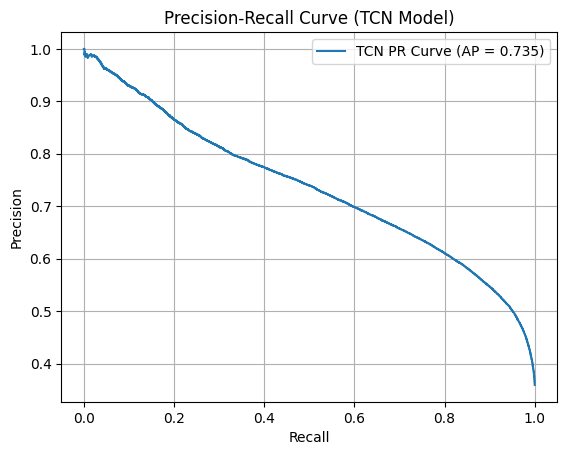

In [14]:
# Get model probabilities for TCN
y_scores_tcn = tcn_model.predict(X_test_tcn).ravel()

# Calculate precision-recall curve
precision_tcn, recall_tcn, thresholds_tcn = precision_recall_curve(
    y_test_tcn,
    y_scores_tcn
)

# Calculate PR-AUC / Average Precision
ap_tcn = average_precision_score(y_test_tcn, y_scores_tcn)

# Plot
plt.figure()
plt.plot(recall_tcn, precision_tcn, label=f"TCN PR Curve (AP = {ap_tcn:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (TCN Model)")
plt.legend()
plt.grid()
plt.show()

In [15]:
threshold = 0.40
y_pred_tcn = (y_scores_tcn >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_tcn, y_pred_tcn).ravel()

print(f"True negatives (predicted safe, was safe): {tn:,}")
print(f"False Positive (predicted incident, was safe): {fp:,} false alarms)")
print(f"False Negatives (predicted safe, was an incident) {fn:,} <- This is the danger, must be low")
print(f"True Positives (predicted incident, was an incident): {tp:,}")

True negatives (predicted safe, was safe): 85,834
False Positive (predicted incident, was safe): 19,346 false alarms)
False Negatives (predicted safe, was an incident) 19,549 <- This is the danger, must be low
True Positives (predicted incident, was an incident): 39,404


In [16]:
def optimize_recall_tcn(modelo, X_test_tcn, y_test_tcn, new_threshold=0.40):

    # The TCN already outputs the probability of class 1 because
    # the final layer uses Dense(1, activation="sigmoid")
    probabilities = modelo.predict(X_test_tcn).ravel()

    # Apply new threshold
    adjusted_predictions = (probabilities >= new_threshold).astype(int)

    print("New Threshold report:")
    print(classification_report(y_test_tcn, adjusted_predictions))

    # Extract confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_tcn, adjusted_predictions).ravel()

    print("Adjusted Confusion matrix")
    print(f"True negatives: {tn:,}")
    print(f"False Positive (false alarms): {fp:,} <- may increase as the cost of higher recall")
    print(f"False Negatives  (danger cases): {fn:,} <- should decrease")
    print(f"True Positives (captured incidents): {tp:,} <- should increase")

In [17]:
predicciones_optimas = optimize_recall_tcn(tcn_model, X_test_tcn, y_test_tcn, new_threshold=0.40)

5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
New Threshold report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82    105180
           1       0.67      0.67      0.67     58953

    accuracy                           0.76    164133
   macro avg       0.74      0.74      0.74    164133
weighted avg       0.76      0.76      0.76    164133

Adjusted Confusion matrix
True negatives: 85,834
False Positive (false alarms): 19,346 <- may increase as the cost of higher recall
False Negatives  (danger cases): 19,549 <- should decrease
True Positives (captured incidents): 39,404 <- should increase


In [18]:
# Function to tune TCN hyperparameters and threshold using validation performance
def hyperparameter_tuning_tcn(
    X_train_tcn,
    y_train_tcn,
    window_size
):

    # Get number of input features per timestep
    n_features = X_train_tcn.shape[2]

    # Minimum acceptable precision while maximizing recall
    min_precision = 0.65

    # Define validation size for metric calculation
    val_size = int(len(X_train_tcn) * 0.2)

    # Split training data into final training subset and validation subset
    X_train_tcn_final = X_train_tcn[:-val_size]
    y_train_tcn_final = y_train_tcn[:-val_size]

    X_val_tcn = X_train_tcn[-val_size:]
    y_val_tcn = y_train_tcn[-val_size:]

    # Define hyperparameter search space
    parameters_space = {
        "filters": [32, 64],
        "dense_units": [16, 32],
        "dropout_rate": [0.2, 0.3],
        "batch_size": [64]
    }

    # Generate all hyperparameter combinations
    combinations = list(itertools.product(
        parameters_space["filters"],
        parameters_space["dense_units"],
        parameters_space["dropout_rate"],
        parameters_space["batch_size"]
    ))

    # Store tuning results
    results = []

    # Start execution timer
    start = time.time()

    # Train one model per hyperparameter combination
    for filters, dense_units, dropout_rate, batch_size in combinations:

        # Print current configuration
        print(
            f"Training: TCN={filters}, "
            f"Dense={dense_units}, "
            f"Dropout={dropout_rate}, "
            f"Batch={batch_size}"
        )

        # Build model with current hyperparameters
        model = build_tcn_model(
            window_size=window_size,
            n_features=n_features,
            filters=filters,
            kernel_size=3,
            dense_units=dense_units,
            dropout_rate=dropout_rate
        )

        # Stop training when validation loss stops improving
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        # Train model using temporal validation data
        history_tcn = model.fit(
            X_train_tcn_final,
            y_train_tcn_final,
            validation_data=(X_val_tcn, y_val_tcn),
            epochs=20,
            batch_size=batch_size,
            callbacks=[early_stop],
            class_weight=class_weights,
            shuffle=False,
            verbose=0
        )

        # Predict probabilities on validation subset
        probabilities = model.predict(X_val_tcn).ravel()

        # Compute PR-AUC using validation probabilities
        pr_auc = average_precision_score(y_val_tcn, probabilities)

        # Search best threshold by maximizing recall with minimum precision constraint
        best_threshold = 0.0
        best_precision = 0.0
        best_recall = 0.0
        best_f1 = 0.0

        for current_threshold in np.arange(0.10, 0.91, 0.05):
            predictions = (probabilities >= current_threshold).astype(int)

            current_precision = precision_score(
                y_val_tcn,
                predictions,
                zero_division=0
            )

            current_recall = recall_score(
                y_val_tcn,
                predictions,
                zero_division=0
            )

            current_f1 = f1_score(
                y_val_tcn,
                predictions,
                zero_division=0
            )

            if current_precision >= min_precision and current_recall > best_recall:
                best_precision = current_precision
                best_recall = current_recall
                best_f1 = current_f1
                best_threshold = current_threshold

        # Fallback to best F1-score if no threshold reaches the minimum precision
        if best_threshold == 0.0:
            for current_threshold in np.arange(0.10, 0.91, 0.05):
                predictions = (probabilities >= current_threshold).astype(int)

                current_precision = precision_score(
                    y_val_tcn,
                    predictions,
                    zero_division=0
                )

                current_recall = recall_score(
                    y_val_tcn,
                    predictions,
                    zero_division=0
                )

                current_f1 = f1_score(
                    y_val_tcn,
                    predictions,
                    zero_division=0
                )

                if current_f1 > best_f1:
                    best_precision = current_precision
                    best_recall = current_recall
                    best_f1 = current_f1
                    best_threshold = current_threshold

        # Save current experiment results
        results.append({
            "filters": filters,
            "dense_units": dense_units,
            "dropout_rate": dropout_rate,
            "batch_size": batch_size,
            "epochs_trained": len(history_tcn.history["loss"]),
            "best_threshold": best_threshold,
            "precision": best_precision,
            "recall": best_recall,
            "f1": best_f1,
            "pr_auc": pr_auc,
            "model": model
        })

    # End execution timer
    end = time.time()

    # Sort models by recall first, then PR-AUC, while respecting the precision constraint
    results = sorted(
        results,
        key=lambda x: (x["recall"], x["pr_auc"]),
        reverse=True
    )

    # Select best configuration based on recall-oriented validation performance
    best_result = results[0]

    # Convert execution time to minutes
    execution_minutes = (end - start) / 60

    # Print tuning summary
    print(f"Tiempo de ejecución: {execution_minutes:.2f} minutos")
    print("LA ARQUITECTURA GANADORA ES:")
    print(f"-> filters: {best_result['filters']}")
    print(f"-> dense_units: {best_result['dense_units']}")
    print(f"-> dropout_rate: {best_result['dropout_rate']}")
    print(f"-> batch_size: {best_result['batch_size']}")
    print(f"-> epochs_trained: {best_result['epochs_trained']}")
    print(f"-> best_threshold: {best_result['best_threshold']:.2f}")
    print(f"\nMejor Score (PR-AUC) en validación: {best_result['pr_auc']:.4f}")
    print(f"Precision en validación: {best_result['precision']:.4f}")
    print(f"Recall en validación: {best_result['recall']:.4f}")
    print(f"F1 en validación: {best_result['f1']:.4f}")

    # Return best model, best threshold, all experiment results, and execution time
    return best_result["model"], best_result["best_threshold"], results, execution_minutes

In [ ]:
def save_run_metrics(
    model_name,
    run_id,
    y_true,
    y_proba,
    execution_time_minutes,
    threshold=0.40,
    csv_path="../results/tcn_results.csv",
    extra_info=None
):

    # Create the results directory if it does not exist
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    # Convert probabilities into binary predictions using the selected threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Extract confusion matrix values for detailed evaluation
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Store all evaluation metrics and experiment metadata in a dictionary
    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": model_name,
        "run_id": run_id,
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "execution_time_minutes": execution_time_minutes
    }

    # Add optional extra experiment information if provided
    if extra_info is not None:
        row.update(extra_info)

    # Append results to the existing CSV file if it already exists
    if os.path.exists(csv_path):
        results_df = pd.read_csv(csv_path)
        results_df = pd.concat(
            [results_df, pd.DataFrame([row])],
            ignore_index=True
        )

    # Create a new dataframe if this is the first experiment run
    else:
        results_df = pd.DataFrame([row])

    # Save the updated results dataframe to disk
    results_df.to_csv(csv_path, index=False)

    # Return the stored metrics for immediate inspection
    return row

In [20]:
# Perform TCN hyperparameter tuning using validation performance
hyperparameterized_tcn_model, winner_threshold, tcn_tuning_results, execution_minutes = hyperparameter_tuning_tcn(
    X_train_tcn,
    y_train_tcn,
    window_size=window_size
)

Training: TCN=32, Dense=16, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Training: TCN=32, Dense=16, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Training: TCN=32, Dense=32, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Training: TCN=32, Dense=32, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Training: TCN=64, Dense=16, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Training: TCN=64, Dense=16, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Training: TCN=64, Dense=32, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Training: TCN=64, Dense=32, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Tiempo de ejecución: 54.64 minutos
LA ARQUITECTURA GANADORA ES:
-> filters: 64
-> dense_units: 16
-> dropout_rate: 0.3
-> batch_size: 64
-> epochs_trained: 7
-> best_threshold: 0.40

Mejor Score (PR-AUC) en validación: 0.3044
Precision en validación: 0.302

In [21]:
def final_model_evaluation_tcn(modelo_campeon, X_test_tcn, y_test_tcn, umbral=0.40):
    print("--- STARTING FINAL EVALUATION TCN ON FUTURE DATA (2025) ---")

    # The TCN already outputs probabilities through the sigmoid layer
    probabilidades = modelo_campeon.predict(X_test_tcn).ravel()

    # Apply the selected decision threshold
    predicciones_finales = (probabilidades >= umbral).astype(int)

    print(f"\nPERFORMANCE REPORT (UMBRAL: {umbral * 100:.0f}%)")
    print("=" * 50)
    print(classification_report(y_test_tcn, predicciones_finales))

    # Final confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_tcn, predicciones_finales).ravel()

    print("\nFINAL CONFUSION MATRIX:")
    print(f"True negatives (safe hours): {tn:,}")
    print(f"Falsos Positivos (false alarms): {fp:,}")
    print(f"False negatives (missed incidents): {fn:,}")
    print(f"True positives (captured incidents): {tp:,}")

    # Métricas de negocio
    recall_final = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_final = tp / (tp + fp) if (tp + fp) > 0 else 0

    print("\nBUSINESS METRICS (CIVIL PROTECTION):")
    print(f"-> Capture rate (Recall): {recall_final * 100:.1f}% de las inundaciones fueron detectadas.")
    print(f"-> Precision de Alarma: {precision_final * 100:.1f}% de las alertas fueron reales.")

    return {
        "threshold": umbral,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "recall": recall_final,
        "precision": precision_final
    }

In [22]:
tcn_final_results = final_model_evaluation_tcn(
    hyperparameterized_tcn_model,
    X_test_tcn,
    y_test_tcn,
    umbral=0.40
)

--- STARTING FINAL EVALUATION TCN ON FUTURE DATA (2025) ---
5130/5130 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step

PERFORMANCE REPORT (UMBRAL: 40%)
              precision    recall  f1-score   support

           0       0.70      0.94      0.80    105180
           1       0.72      0.29      0.41     58953

    accuracy                           0.70    164133
   macro avg       0.71      0.61      0.61    164133
weighted avg       0.71      0.70      0.66    164133


FINAL CONFUSION MATRIX:
True negatives (safe hours): 98,762
Falsos Positivos (false alarms): 6,418
False negatives (missed incidents): 42,109
True positives (captured incidents): 16,844

BUSINESS METRICS (CIVIL PROTECTION):
-> Capture rate (Recall): 28.6% de las inundaciones fueron detectadas.
-> Precision de Alarma: 72.4% de las alertas fueron reales.


5130/5130 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


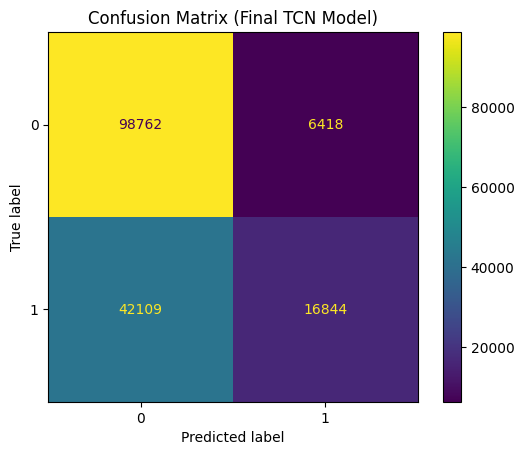

In [23]:
y_pred_final_tcn = (
    hyperparameterized_tcn_model
    .predict(X_test_tcn)
    .ravel() >= 0.40
).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test_tcn,
    y_pred_final_tcn
)

plt.title("Confusion Matrix (Final TCN Model)")
plt.show()

Unlike XGBoost, the TCN model does not provide direct feature-importance metrics because it learns distributed temporal representations.

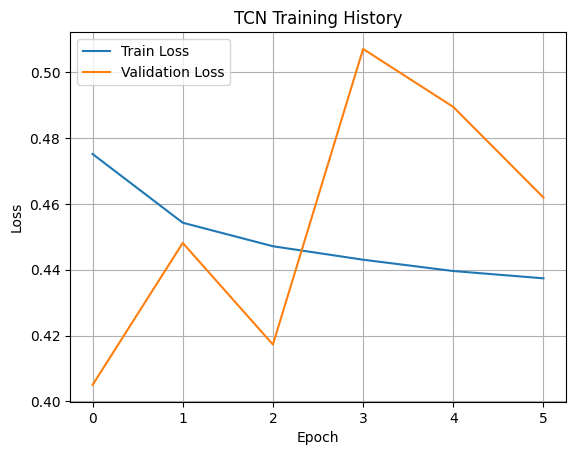

In [24]:
plt.plot(history_tcn.history["loss"], label="Train Loss")
plt.plot(history_tcn.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TCN Training History")

plt.legend()
plt.grid()

plt.show()

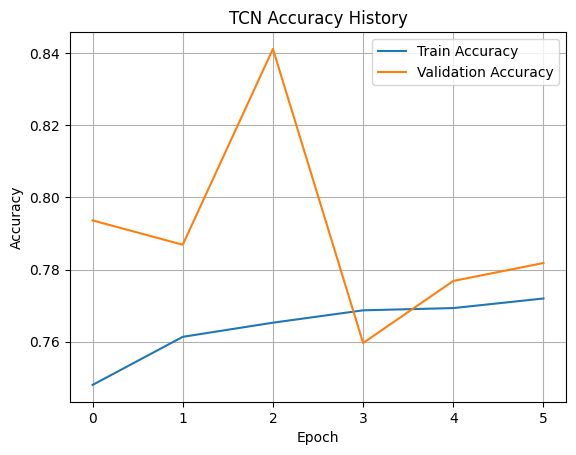

In [25]:
plt.plot(history_tcn.history["accuracy"], label="Train Accuracy")
plt.plot(history_tcn.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TCN Accuracy History")

plt.legend()
plt.grid()

plt.show()

In [29]:
TOTAL_RUNS = 5

for run in range(1, TOTAL_RUNS + 1):

    print("=" * 60)
    print(f"STARTING RUN {run}/{TOTAL_RUNS}")
    print("=" * 60)

    # Train and tune the TCN model
    hyperparameterized_tcn_model, winner_threshold, tcn_tuning_results, execution_minutes = hyperparameter_tuning_tcn(
        X_train_tcn,
        y_train_tcn,
        window_size=window_size
    )

    # Perform final evaluation on the test set
    final_results = final_model_evaluation_tcn(
        hyperparameterized_tcn_model,
        X_test_tcn,
        y_test_tcn,
        umbral=winner_threshold
    )

    # Predict probabilities on the test set
    y_proba = hyperparameterized_tcn_model.predict(X_test_tcn).ravel()

    # Save metrics automatically into CSV
    save_run_metrics(
        model_name="TCN",
        run_id=run,
        y_true=y_test_tcn,
        y_proba=y_proba,
        execution_time_minutes=execution_minutes,
        threshold=winner_threshold,
        csv_path="../results/tcn_results.csv"
    )

    print(f"RUN {run} COMPLETED")

    # Clear TensorFlow and Python memory between runs
    del hyperparameterized_tcn_model
    del tcn_tuning_results

    tf.keras.backend.clear_session()
    gc.collect()

STARTING RUN 1/5
Training: TCN=32, Dense=16, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Training: TCN=32, Dense=16, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Training: TCN=32, Dense=32, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Training: TCN=32, Dense=32, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Training: TCN=64, Dense=16, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Training: TCN=64, Dense=16, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Training: TCN=64, Dense=32, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Training: TCN=64, Dense=32, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Tiempo de ejecución: 66.12 minutos
LA ARQUITECTURA GANADORA ES:
-> filters: 32
-> dense_units: 16
-> dropout_rate: 0.2
-> batch_size: 64
-> epochs_trained: 7
-> best_threshold: 0.45

Mejor Score (PR-AUC) en validación: 0.2691
Precision e

C:\Users\eldeivid\AppData\Local\Temp\ipykernel_9304\4176741364.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat(


STARTING RUN 2/5
Training: TCN=32, Dense=16, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Training: TCN=32, Dense=16, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Training: TCN=32, Dense=32, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Training: TCN=32, Dense=32, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
Training: TCN=64, Dense=16, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Training: TCN=64, Dense=16, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Training: TCN=64, Dense=32, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Training: TCN=64, Dense=32, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Tiempo de ejecución: 65.56 minutos
LA ARQUITECTURA GANADORA ES:
-> filters: 64
-> dense_units: 16
-> dropout_rate: 0.3
-> batch_size: 64
-> epochs_trained: 7
-> best_threshold: 0.50

Mejor Score (PR-AUC) en validación: 0.2679
Precision en